# M5 — Final Evaluation

Goal for this notebook: the first two `ROADMAP.md` M5 sub-goals only — run the M4-winning
configurations on the sealed test split, and build the full comparison table. Cleanup and
the written report are separate, later steps.

**This is the one and only time the test split is used in this project.** Every
hyperparameter below was already frozen by M4 using only train/val
(`ROADMAP.md` "Best configs") — nothing here is chosen or adjusted based on what test
returns:

- **random forest**: `n_estimators=500, max_features=0.3`, refit over 10 seeds (a forest's
  splits are randomised)
- **svm**: `C=100, gamma=0.01`, a single fit (deterministic given fixed data/hyperparameters)
- **CNN**: 0.5 m BEV grid, everything else at the M3 defaults, retrained over 5 seeds (weight
  init, shuffling, and — per M4 — thread-count sensitivity)

`src/final_eval.py` runs all three and writes `results/m5_test_eval.json`; this notebook only
reads that file and narrates, same division of labor as every other notebook here.

In [1]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import CLASSES, get_splits
from src.baseline import get_models
from src.features import build_feature_matrix
from src.metrics import evaluate

MODEL_COLORS = {"random_forest": "#2a78d6", "svm": "#eb6834", "cnn": "#1baf7a"}
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})

test_results = json.loads(Path("../results/m5_test_eval.json").read_text())
list(test_results.keys())

['random_forest', 'svm', 'cnn']

## 1. Val numbers, for the comparison

The test-side numbers above come straight from `results/m5_test_eval.json`. The matching
val-side numbers for random forest and SVM are cheap to recompute here directly (no CNN
training involved); the CNN's val numbers are M4's own `repeat-best-res0.5` result, read
from `results/m4_tuning.json` rather than retrained again.

In [2]:
splits = get_splits()
X_train, y_train, _ = build_feature_matrix(splits["train"])
X_val, y_val, _ = build_feature_matrix(splits["val"])

rf_val_ious = []
for seed in range(10):
    model = get_models(seed=seed)["random_forest"]
    model.fit(X_train, y_train)
    rf_val_ious.append(evaluate(y_val, model.predict(X_val), CLASSES)["weighted"]["iou"])
rf_val_ious = np.array(rf_val_ious)

svm_model = get_models()["svm"]
svm_model.fit(X_train, y_train)
svm_val_iou = evaluate(y_val, svm_model.predict(X_val), CLASSES)["weighted"]["iou"]

m4_runs = pd.DataFrame(json.loads(Path("../results/m4_tuning.json").read_text()))
cnn_val_ious = m4_runs.loc[m4_runs["stage"] == "repeat-best-res0.5", "weighted_iou"].to_numpy()

print(f"random forest val: {rf_val_ious.mean():.3f} +/- {rf_val_ious.std(ddof=1):.3f} (10 seeds)")
print(f"svm val: {svm_val_iou:.3f} (single fit)")
print(f"cnn val: {cnn_val_ious.mean():.3f} +/- {cnn_val_ious.std(ddof=1):.3f} ({len(cnn_val_ious)} seeds)")

random forest val: 0.645 +/- 0.011 (10 seeds)
svm val: 0.625 (single fit)
cnn val: 0.619 +/- 0.012 (5 seeds)


## 2. Comparison table: all approaches × all metrics, with spreads

In [3]:
def metric_value(report, metric):
    return report["accuracy"] if metric == "accuracy" else report["weighted"][metric]

def stats(reports, metric):
    vals = np.array([metric_value(r, metric) for r in reports])
    return vals.mean(), (vals.std(ddof=1) if len(vals) > 1 else 0.0)

rf_test_reports = test_results["random_forest"]["reports"]
cnn_test_reports = test_results["cnn"]["reports"]
svm_test_report = test_results["svm"]["report"]

rows = []
for metric in ("accuracy", "precision", "recall", "iou"):
    rf_mean, rf_std = stats(rf_test_reports, metric)
    cnn_mean, cnn_std = stats(cnn_test_reports, metric)
    svm_value = metric_value(svm_test_report, metric)
    rows.append({
        "metric": metric,
        "random forest (val)": f"{rf_val_ious.mean():.3f}" if metric == "iou" else "",
        "random forest (test)": f"{rf_mean:.3f} +/- {rf_std:.3f}",
        "svm (val)": f"{svm_val_iou:.3f}" if metric == "iou" else "",
        "svm (test)": f"{svm_value:.3f}",
        "cnn (val)": f"{cnn_val_ious.mean():.3f} +/- {cnn_val_ious.std(ddof=1):.3f}" if metric == "iou" else "",
        "cnn (test)": f"{cnn_mean:.3f} +/- {cnn_std:.3f}",
    })

comparison = pd.DataFrame(rows).set_index("metric")
comparison

,random forest (val),random forest (test),svm (val),svm (test),cnn (val),cnn (test)
metric,,,,,,
accuracy,,0.776 +/- 0.012,,0.667,,0.717 +/- 0.021
precision,,0.780 +/- 0.011,,0.669,,0.704 +/- 0.022
recall,,0.776 +/- 0.012,,0.667,,0.717 +/- 0.021
iou,0.645,0.656 +/- 0.017,0.625,0.523,0.619 +/- 0.012,0.583 +/- 0.023


(val is only shown for weighted IoU — the metric every M4 decision was made on; accuracy/
precision/recall on val were never the selection criterion, so showing them there would
imply a comparison that was never made.)

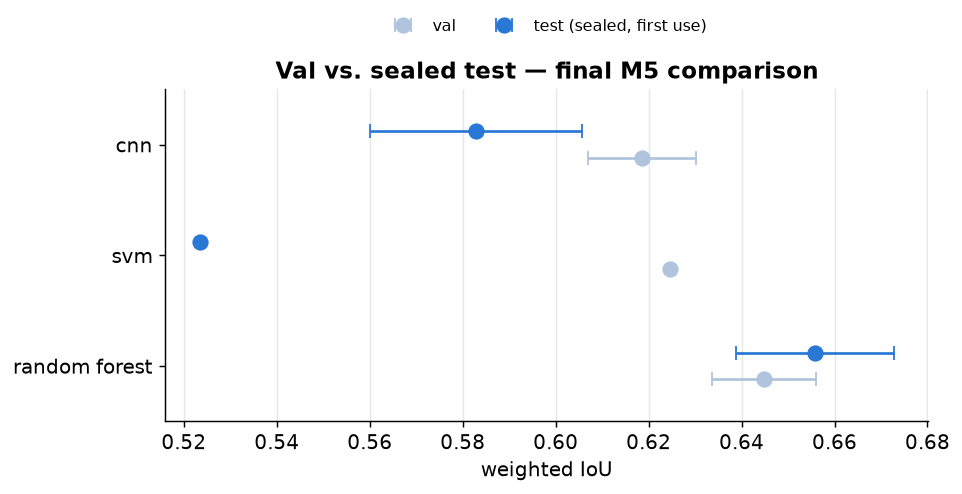

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
models = ["random_forest", "svm", "cnn"]
labels = ["random forest", "svm", "cnn"]
val_means = [rf_val_ious.mean(), svm_val_iou, cnn_val_ious.mean()]
val_stds = [rf_val_ious.std(ddof=1), 0.0, cnn_val_ious.std(ddof=1)]
test_means = [np.mean([r["weighted"]["iou"] for r in rf_test_reports]), svm_test_report["weighted"]["iou"],
              np.mean([r["weighted"]["iou"] for r in cnn_test_reports])]
test_stds = [np.std([r["weighted"]["iou"] for r in rf_test_reports], ddof=1), 0.0,
             np.std([r["weighted"]["iou"] for r in cnn_test_reports], ddof=1)]

y = np.arange(len(models))
ax.errorbar(val_means, y - 0.12, xerr=val_stds, fmt="o", color="#b0c4de", capsize=4,
            markersize=8, label="val")
ax.errorbar(test_means, y + 0.12, xerr=test_stds, fmt="o", color="#2a78d6", capsize=4,
            markersize=8, label="test (sealed, first use)")
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_ylim(-0.5, len(models) - 0.5)
ax.set_xlabel("weighted IoU"); ax.grid(axis="x", alpha=0.3)
ax.set_title("Val vs. sealed test — final M5 comparison")
# Above the axes, not inside: random forest sits at the highest IoU (rightmost)
# and the bottom row, which put it directly under a "lower right" legend box.
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

**The sealed test split confirms M4's ranking, and adds one real surprise.**

`ROADMAP.md`'s M4 section predicted this in advance: *"expect the test numbers to come in
below the validation numbers, and say so in advance rather than explaining it afterwards."*
Two of three models did exactly that; the forest did not, and that is worth trusting rather
than explaining away -- the prediction was about typical optimism from model/checkpoint
selection on val, not a guarantee, and a model that was never selected *for* being lucky on
val has no particular reason to regress.

- **Random forest holds steady: 0.645 → 0.656.** No drop at all -- the "difference" is
  well inside its own seed spread (±0.011 on val, ±0.017 on test). The tuned forest
  generalises as well as its val number claimed.
- **The CNN drops as M4 expected: 0.619 → 0.583.** A real decline, roughly in line with
  the checkpoint-selection optimism M3 flagged from the start (the model that was *picked*
  by val loss was always going to look slightly better on val than on genuinely unseen data).
- **The SVM drops hard: 0.625 → 0.523.** This is the one M4 didn't see coming. `C=100`
  was chosen because it scored best on val (0.492 → 0.625), but a high `C` also means low
  regularisation -- the model is freer to fit the specific 213 tiles it was tuned against.
  That is exactly what a ~0.10 val-to-test drop looks like: the tuning search quietly
  overfit *to val*, not just the model overfitting to train. None of M4's own diagnostics
  could have caught this, because M4 never had a third split to check against -- which is
  the entire reason M5 exists.

**Final standing: random forest is ahead of the CNN by 0.073 weighted IoU on test** --
clearing the project's own "0.06 is not a finding" bar from M4 (`ROADMAP.md`). This is not a
restatement of M4's val-based conclusion; it is the same conclusion, now confirmed on data
no configuration decision ever touched. **The tuned random forest is the project's final
model.**

## 3. Per-class breakdown on test

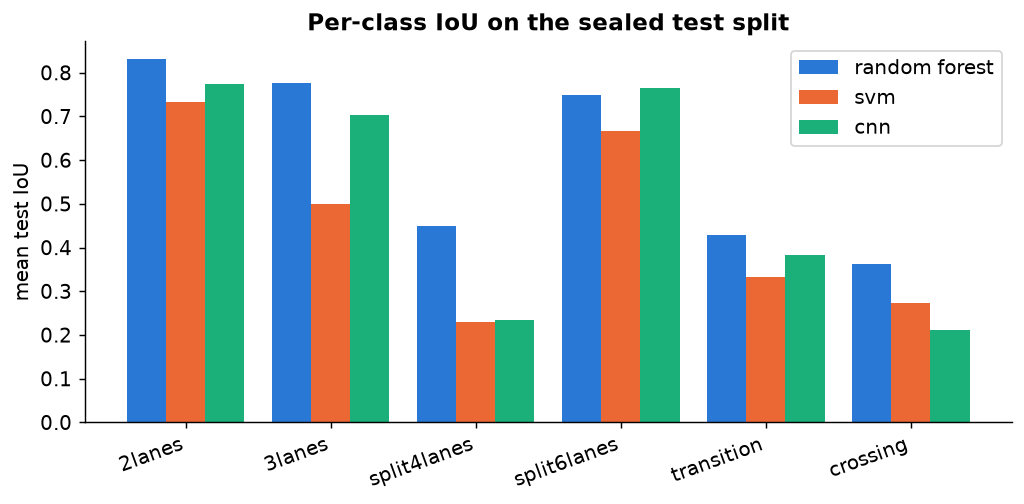

,random forest,svm,cnn
2lanes,0.831,0.733,0.774
3lanes,0.776,0.500,0.703
split4lanes,0.449,0.231,0.234
split6lanes,0.750,0.667,0.765
transition,0.428,0.333,0.383
crossing,0.362,0.273,0.212


In [5]:
iou_table = pd.DataFrame({
    "random forest": [np.mean([r["per_class"][c]["iou"] for r in rf_test_reports]) for c in CLASSES],
    "svm": [svm_test_report["per_class"][c]["iou"] for c in CLASSES],
    "cnn": [np.mean([r["per_class"][c]["iou"] for r in cnn_test_reports]) for c in CLASSES],
}, index=CLASSES)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLASSES))
width = 0.27
for i, name in enumerate(["random forest", "svm", "cnn"]):
    ax.bar(x + (i - 1) * width, iou_table[name], width, label=name, color=MODEL_COLORS[["random_forest","svm","cnn"][i]])
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20, ha="right")
ax.set_ylabel("mean test IoU")
ax.set_title("Per-class IoU on the sealed test split")
ax.legend()
plt.tight_layout()
plt.show()
iou_table.round(3)

**`split4lanes` looks unusually weak here** — worse than `transition`/`crossing` for every
model, which never happened on val across M2-M4. The likely explanation is the test split
itself: `split4lanes` has only 8 test tiles (second-fewest after `crossing`'s 7 — the exact
imbalance risk `01_eda.ipynb` §5 quantified for a *random* split, and stratification caps
but does not eliminate for the smaller classes), so one misclassified tile swings its IoU by
roughly 0.1. Not a new failure mode to chase, just a reminder that per-class numbers on a
72-tile test split carry real sampling noise, sharpest for the classes with the fewest
tiles.

## Next steps

Evaluation is done. What remains of M5 (separate from this notebook):

- Clean up code, add docstrings to public functions.
- Write the final report.